# Phase 1: EDA 시각화\n스마트 창고 출고 지연 예측 — 탐색적 데이터 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
train = pd.read_csv('../data/train.csv')
layout = pd.read_csv('../data/layout_info.csv')

# implicit_timeslot 생성
train['implicit_timeslot'] = train.groupby('scenario_id').cumcount()

print(f"Train shape: {train.shape}")
print(f"Layout shape: {layout.shape}")
train.head()

Train shape: (250000, 95)
Layout shape: (300, 15)


,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct,implicit_timeslot
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN,0
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88,1
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40,2
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72,3
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02,4


## 1. 타겟 분포: 원본 + log1p 변환 히스토그램

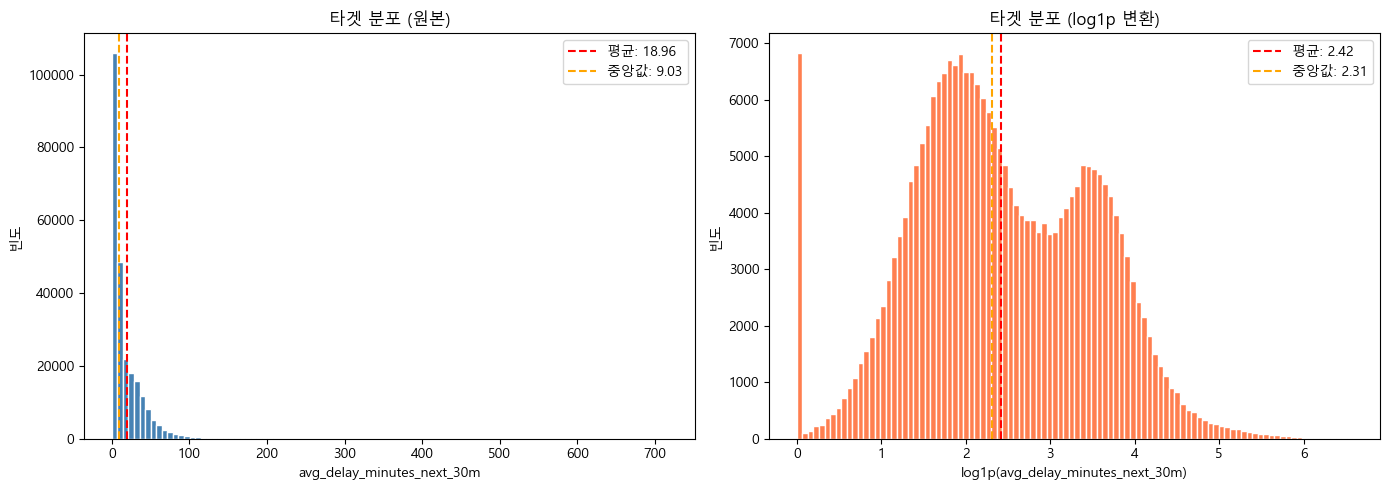

원본 - mean: 18.96, median: 9.03, skew: 5.68, max: 715.86


In [2]:
target = train['avg_delay_minutes_next_30m']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('타겟 분포 (원본)')
axes[0].set_xlabel('avg_delay_minutes_next_30m')
axes[0].set_ylabel('빈도')
axes[0].axvline(target.mean(), color='red', linestyle='--', label=f'평균: {target.mean():.2f}')
axes[0].axvline(target.median(), color='orange', linestyle='--', label=f'중앙값: {target.median():.2f}')
axes[0].legend()

target_log = np.log1p(target)
axes[1].hist(target_log, bins=100, color='coral', edgecolor='white')
axes[1].set_title('타겟 분포 (log1p 변환)')
axes[1].set_xlabel('log1p(avg_delay_minutes_next_30m)')
axes[1].set_ylabel('빈도')
axes[1].axvline(target_log.mean(), color='red', linestyle='--', label=f'평균: {target_log.mean():.2f}')
axes[1].axvline(target_log.median(), color='orange', linestyle='--', label=f'중앙값: {target_log.median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/eda_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"원본 - mean: {target.mean():.2f}, median: {target.median():.2f}, skew: {target.skew():.2f}, max: {target.max():.2f}")

## 2. 타겟 상관관계 Top 30 수평 막대 그래프

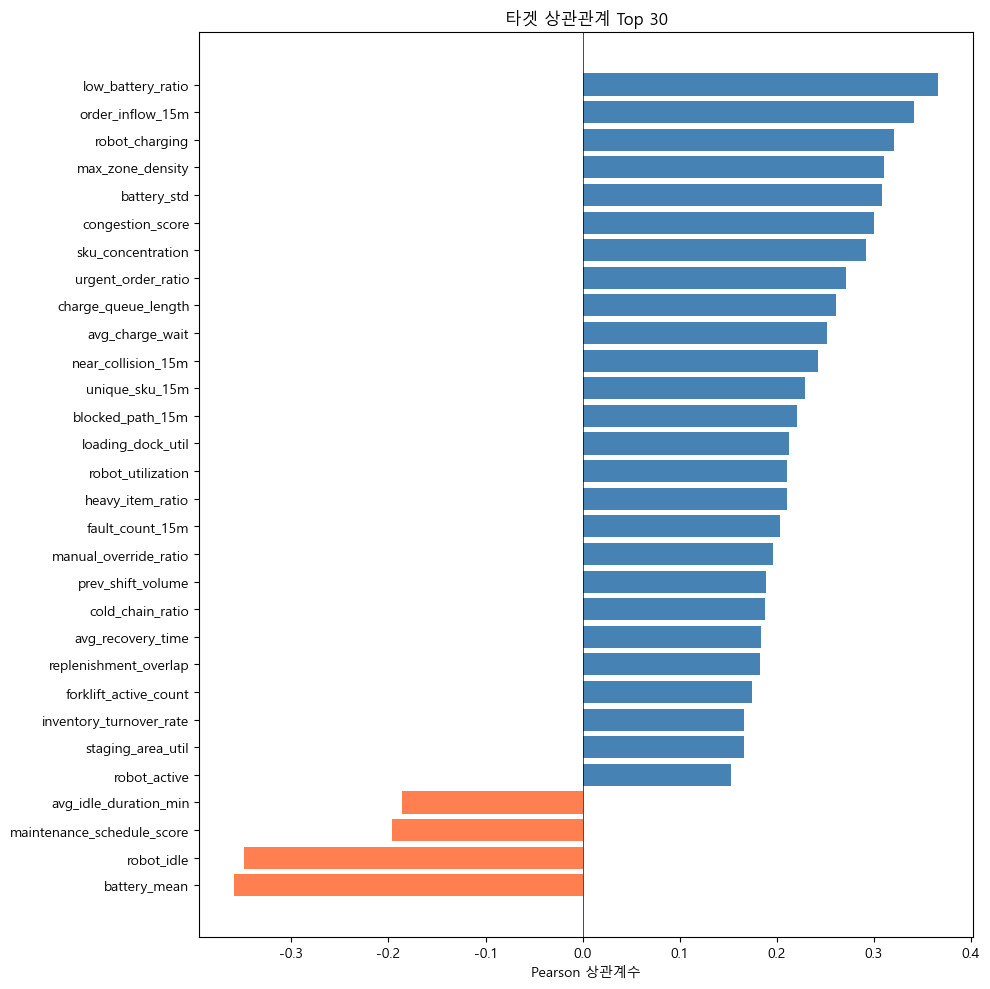

In [3]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()['avg_delay_minutes_next_30m'].drop('avg_delay_minutes_next_30m')
top30 = corr.abs().sort_values(ascending=False).head(30)
top30_vals = corr[top30.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['steelblue' if v > 0 else 'coral' for v in top30_vals.values]
ax.barh(top30_vals.index, top30_vals.values, color=colors)
ax.set_title('타겟 상관관계 Top 30')
ax.set_xlabel('Pearson 상관계수')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../output/eda_02_correlation_top30.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. implicit_timeslot별 타겟 평균 추이

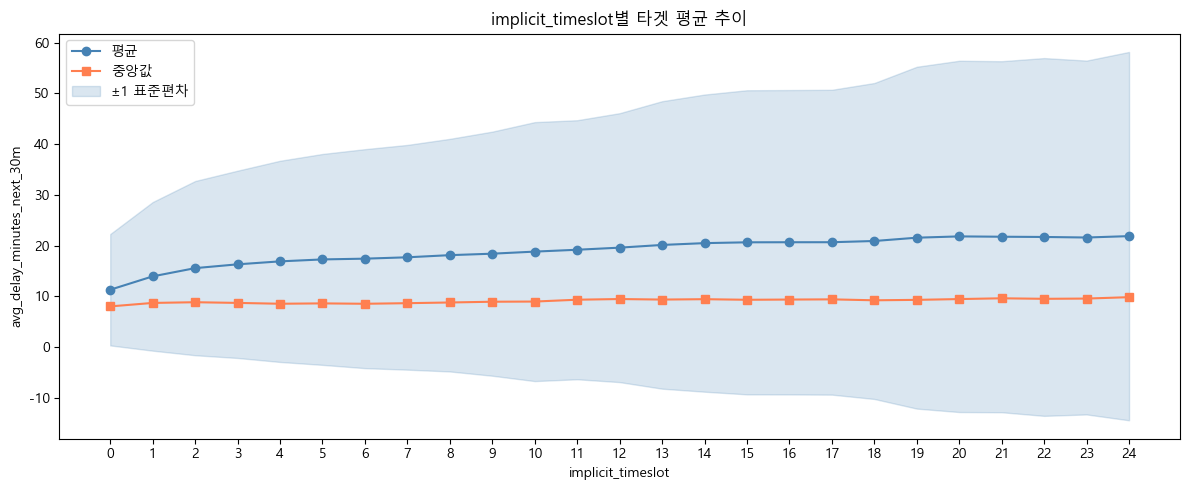

In [4]:
timeslot_stats = train.groupby('implicit_timeslot')['avg_delay_minutes_next_30m'].agg(['mean', 'median', 'std'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(timeslot_stats.index, timeslot_stats['mean'], marker='o', label='평균', color='steelblue')
ax.plot(timeslot_stats.index, timeslot_stats['median'], marker='s', label='중앙값', color='coral')
ax.fill_between(timeslot_stats.index,
                timeslot_stats['mean'] - timeslot_stats['std'],
                timeslot_stats['mean'] + timeslot_stats['std'],
                alpha=0.2, color='steelblue', label='±1 표준편차')
ax.set_title('implicit_timeslot별 타겟 평균 추이')
ax.set_xlabel('implicit_timeslot')
ax.set_ylabel('avg_delay_minutes_next_30m')
ax.legend()
ax.set_xticks(range(25))
plt.tight_layout()
plt.savefig('../output/eda_03_timeslot_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. layout_type별 타겟 분포 박스플롯

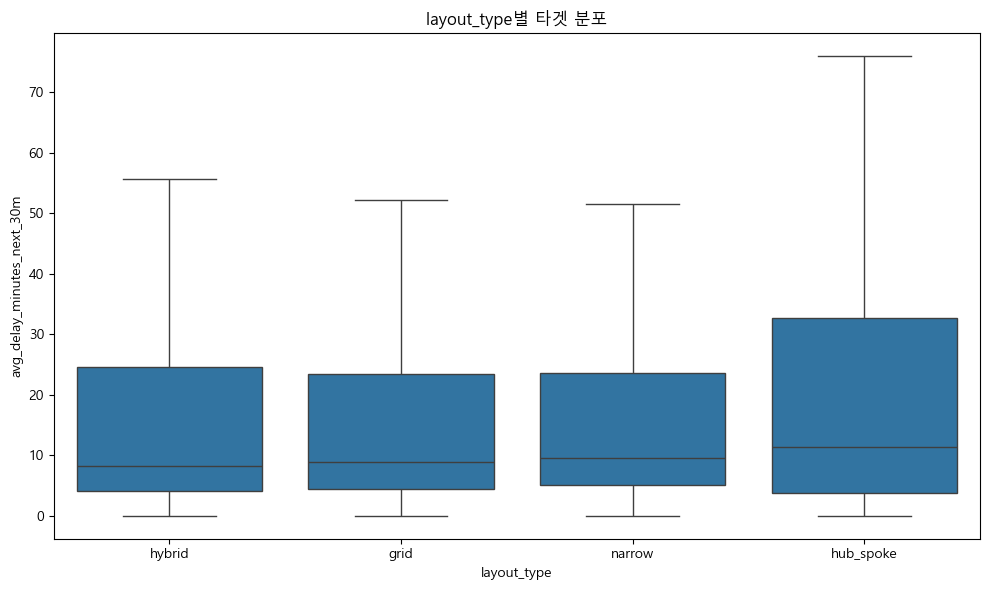

               count   mean    std  min   25%    50%    75%     max
layout_type                                                        
grid         91250.0  18.10  26.25  0.0  4.39   8.92  23.50  715.86
hub_spoke    43375.0  22.28  30.44  0.0  3.71  11.32  32.61  664.76
hybrid       73125.0  18.41  28.28  0.0  4.01   8.25  24.65  659.65
narrow       42250.0  18.36  24.27  0.0  5.09   9.47  23.68  590.13


In [5]:
train_layout = train.merge(layout[['layout_id', 'layout_type']], on='layout_id', how='left')

fig, ax = plt.subplots(figsize=(10, 6))
order = train_layout.groupby('layout_type')['avg_delay_minutes_next_30m'].median().sort_values().index
sns.boxplot(data=train_layout, x='layout_type', y='avg_delay_minutes_next_30m',
            order=order, ax=ax, showfliers=False)
ax.set_title('layout_type별 타겟 분포')
ax.set_xlabel('layout_type')
ax.set_ylabel('avg_delay_minutes_next_30m')
plt.tight_layout()
plt.savefig('../output/eda_04_layout_type_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(train_layout.groupby('layout_type')['avg_delay_minutes_next_30m'].describe().round(2))

## 5. 배터리 관련 피처 vs 타겟 산점도

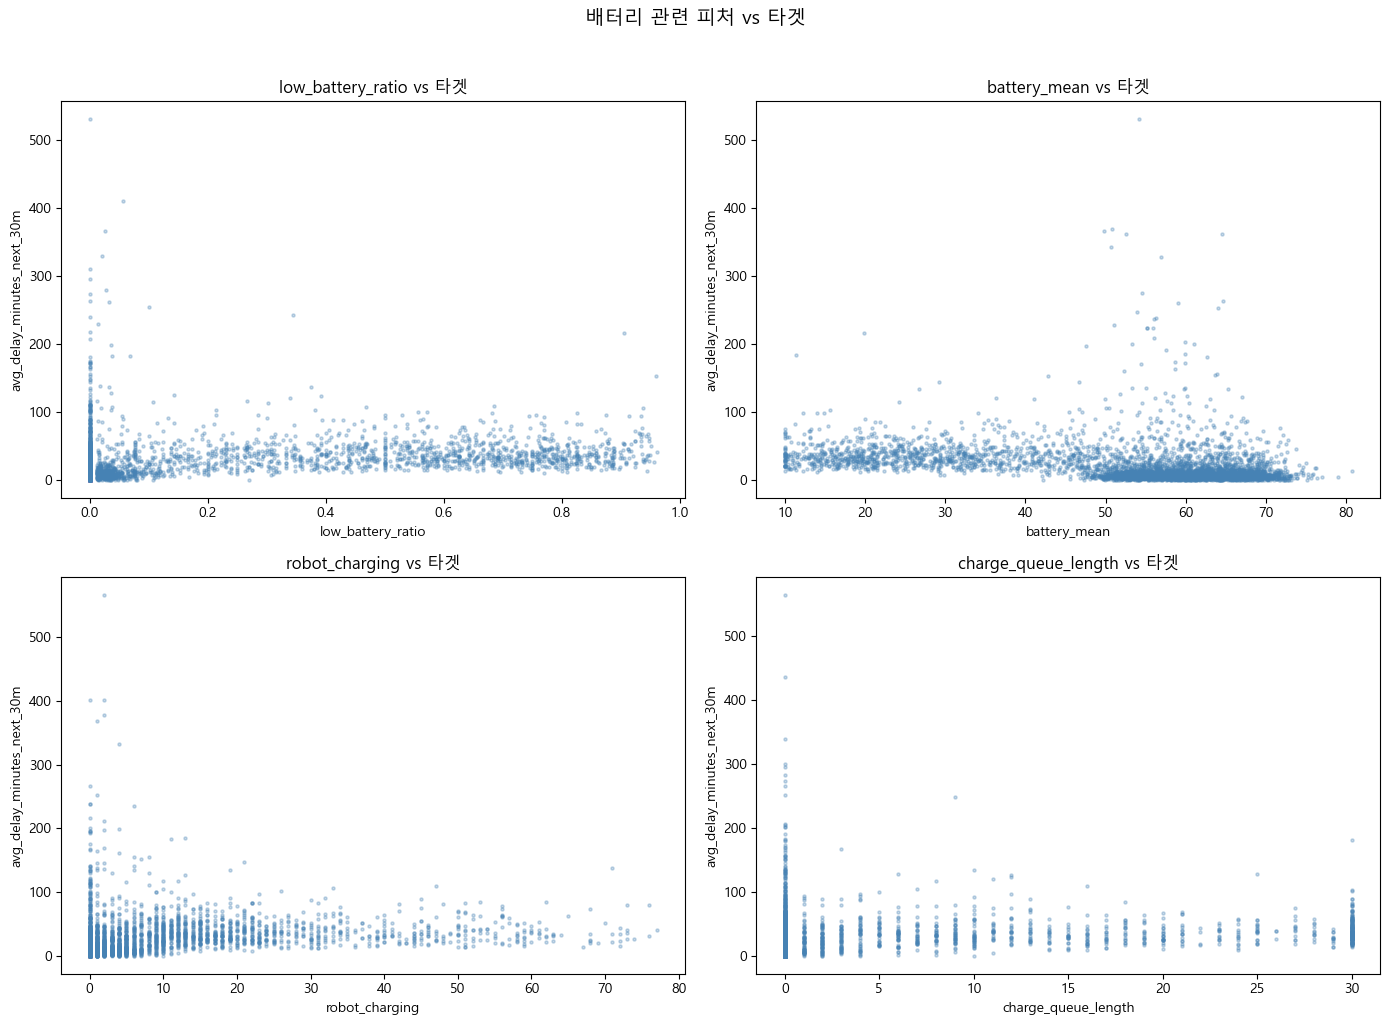

In [6]:
battery_features = ['low_battery_ratio', 'battery_mean', 'robot_charging', 'charge_queue_length']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), battery_features):
    sample = train[[feat, 'avg_delay_minutes_next_30m']].dropna().sample(min(5000, len(train)), random_state=42)
    ax.scatter(sample[feat], sample['avg_delay_minutes_next_30m'], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('avg_delay_minutes_next_30m')
    ax.set_title(f'{feat} vs 타겟')

plt.suptitle('배터리 관련 피처 vs 타겟', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../output/eda_05_battery_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 결측 비율 Top 20 막대 그래프

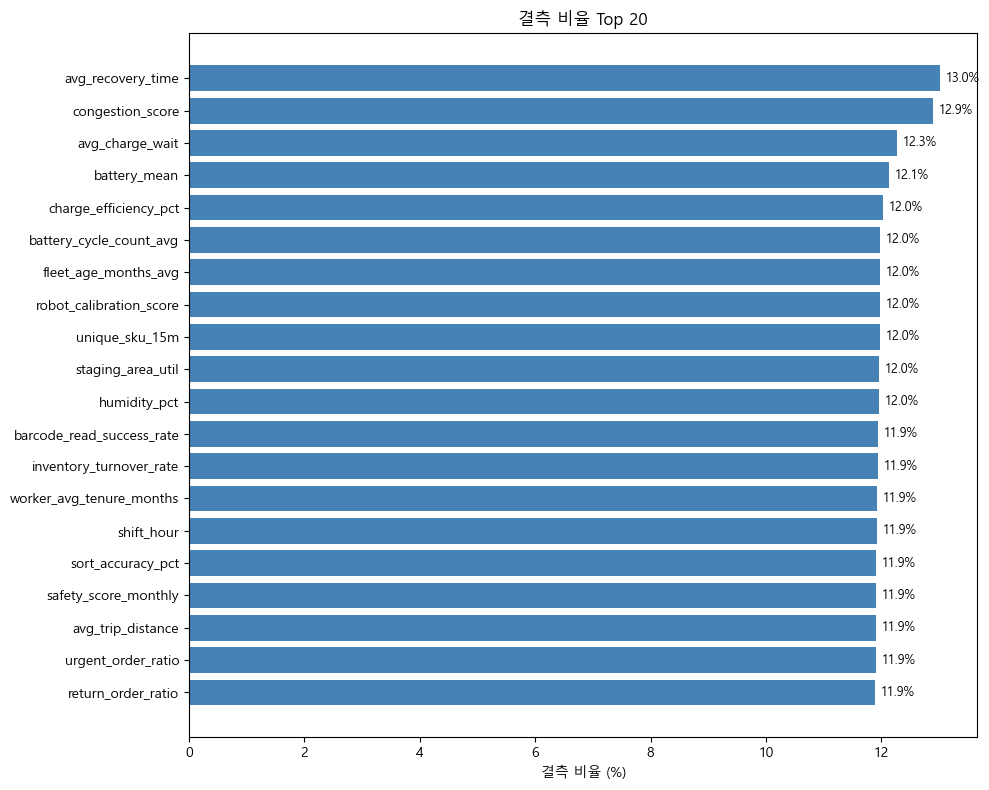

결측이 있는 컬럼 수: 86
결측 비율 범위: 11.73% ~ 13.01%


In [7]:
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_top20 = missing_pct[missing_pct > 0].head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(missing_top20.index[::-1], missing_top20.values[::-1], color='steelblue')
ax.set_title('결측 비율 Top 20')
ax.set_xlabel('결측 비율 (%)')
for i, (val, name) in enumerate(zip(missing_top20.values[::-1], missing_top20.index[::-1])):
    ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../output/eda_06_missing_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"결측이 있는 컬럼 수: {(train.isnull().sum() > 0).sum()}")
print(f"결측 비율 범위: {missing_pct[missing_pct > 0].min():.2f}% ~ {missing_pct.max():.2f}%")